# Row-K Rules: DiT Learning Analysis

**Rule family**: Binary ±1 sequences on a 6×6 grid where each row satisfies a K constraint.

**Model**: DiT-mini (6L, 6H, 384D), N=4096 training samples, 1M steps.

**Variants**:
| Exp | Rule | Description |
|---|---|---|
| rowK2 | row_k K=2 | Every row has exactly 2 ones |
| rowK3 | row_k K=3 | Every row has exactly 3 ones |
| varK{1,5} | row_variable_k K∈{1,5} | Each row independently K=1 or 5 |
| varK{3,4} | row_variable_k K∈{3,4} | Each row independently K=3 or 4 |
| varK{0,2,4,6} | row_variable_k K∈{0,2,4,6} | Each row independently even K |
| varK{3,4,5,6} | row_variable_k K∈{3,4,5,6} | Each row independently K∈{3..6} |
| globalK{1,5} | global_k K∈{1,5} | All rows same K drawn from {1,5} |
| globalK{2,4} | global_k K∈{2,4} | All rows same K drawn from {2,4} |

**Analysis sections**:
1. Training curves (loss, valid, mem, nan_ratio)
2. Valid/mem overlay — memorization onset
3. Grad norm evolution
4. Crash correlation: zoom into late-training mem rise
5. σ-loss evolution (DSM loss vs training step, per σ bin)
6. σ-loss curves at pre/post divergence checkpoints

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from PIL import Image
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIGDIR   = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/rowK_analysis"
SAVE_FIGS = True
os.makedirs(FIGDIR, exist_ok=True)

%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 120

# ── Experiment registry ─────────────────────────────────────────────────────
EXPS = [
    ('rowK2',       'DiT_mini_rowK2_n6_N4096',       '#1f77b4'),
    ('rowK3',       'DiT_mini_rowK3_n6_N4096',       '#aec7e8'),
    ('varK{1,5}',   'DiT_mini_rowVarK15_n6_N4096',   '#ff7f0e'),
    ('varK{3,4}',   'DiT_mini_rowVarK34_n6_N4096',   '#ffbb78'),
    ('varK{0,2,4,6}','DiT_mini_rowVarK0246_n6_N4096','#d62728'),
    ('varK{3,4,5,6}','DiT_mini_rowVarK3456_n6_N4096','#ff9896'),
    ('globalK{1,5}','DiT_mini_globalK15_n6_N4096',   '#2ca02c'),
    ('globalK{2,4}','DiT_mini_globalK24_n6_N4096',   '#98df8a'),
]
LABELS   = [e[0] for e in EXPS]
EXP_NAMES= [e[1] for e in EXPS]
COLORS   = {e[0]: e[2] for e in EXPS}
# rule family linestyle
LS = {'rowK': '-', 'varK': '--', 'globalK': ':'}
def get_ls(label):
    for k, v in LS.items():
        if label.startswith(k): return v
    return '-'

def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ['png', 'pdf']:
            fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=150, bbox_inches='tight')

# ── EMA smoothing ───────────────────────────────────────────────────────────
def ema_smooth(arr, alpha=0.9):
    if len(arr) == 0: return arr
    s = np.zeros_like(arr, dtype=np.float32)
    s[0] = arr[0]
    for i in range(1, len(arr)):
        s[i] = (1 - alpha) * arr[i] + alpha * s[i-1]
    return s

print("Experiments:")
for lbl, exp, _ in EXPS:
    ok = os.path.isdir(os.path.join(SAVEROOT, exp))
    print(f"  {'✓' if ok else '✗'} {lbl:20s}  {exp}")

Experiments:
  ✓ rowK2                 DiT_mini_rowK2_n6_N4096
  ✓ rowK3                 DiT_mini_rowK3_n6_N4096
  ✓ varK{1,5}             DiT_mini_rowVarK15_n6_N4096
  ✓ varK{3,4}             DiT_mini_rowVarK34_n6_N4096
  ✓ varK{0,2,4,6}         DiT_mini_rowVarK0246_n6_N4096
  ✓ varK{3,4,5,6}         DiT_mini_rowVarK3456_n6_N4096
  ✓ globalK{1,5}          DiT_mini_globalK15_n6_N4096
  ✓ globalK{2,4}          DiT_mini_globalK24_n6_N4096


In [2]:
# ── TensorBoard loader ───────────────────────────────────────────────────────
def load_tb(exp_name, tags=None):
    tb_dir = os.path.join(SAVEROOT, exp_name, 'tensorboard')
    ea = EventAccumulator(tb_dir, size_guidance={'scalars': 0})
    ea.Reload()
    available = ea.Tags()['scalars']
    if tags is None: tags = available
    result = {}
    for tag in tags:
        if tag in available:
            events = ea.Scalars(tag)
            result[tag] = {
                'steps': np.array([e.step  for e in events]),
                'vals':  np.array([e.value for e in events]),
            }
    return result

TAGS = ['train/loss', 'train/grad_norm',
        'eval/full_valid_ratio', 'eval/per_row_valid_ratio',
        'eval/nan_ratio', 'eval/sample_mem_ratio', 'eval/row_k_valid']

tb_data = {}
for lbl, exp, _ in EXPS:
    try:
        tb_data[lbl] = load_tb(exp, TAGS)
        last = tb_data[lbl]['train/loss']['steps'][-1]
        print(f"{lbl:20s}: loaded  (last step={last:,})")
    except Exception as e:
        print(f"{lbl:20s}: ERROR — {e}")
        tb_data[lbl] = {}

rowK2               : loaded  (last step=1,000,000)


rowK3               : loaded  (last step=1,000,000)


varK{1,5}           : loaded  (last step=1,000,000)


varK{3,4}           : loaded  (last step=1,000,000)


varK{0,2,4,6}       : loaded  (last step=1,000,000)


varK{3,4,5,6}       : loaded  (last step=1,000,000)


globalK{1,5}        : loaded  (last step=1,000,000)


globalK{2,4}        : loaded  (last step=1,000,000)


## 1. Training curves — all 8 variants

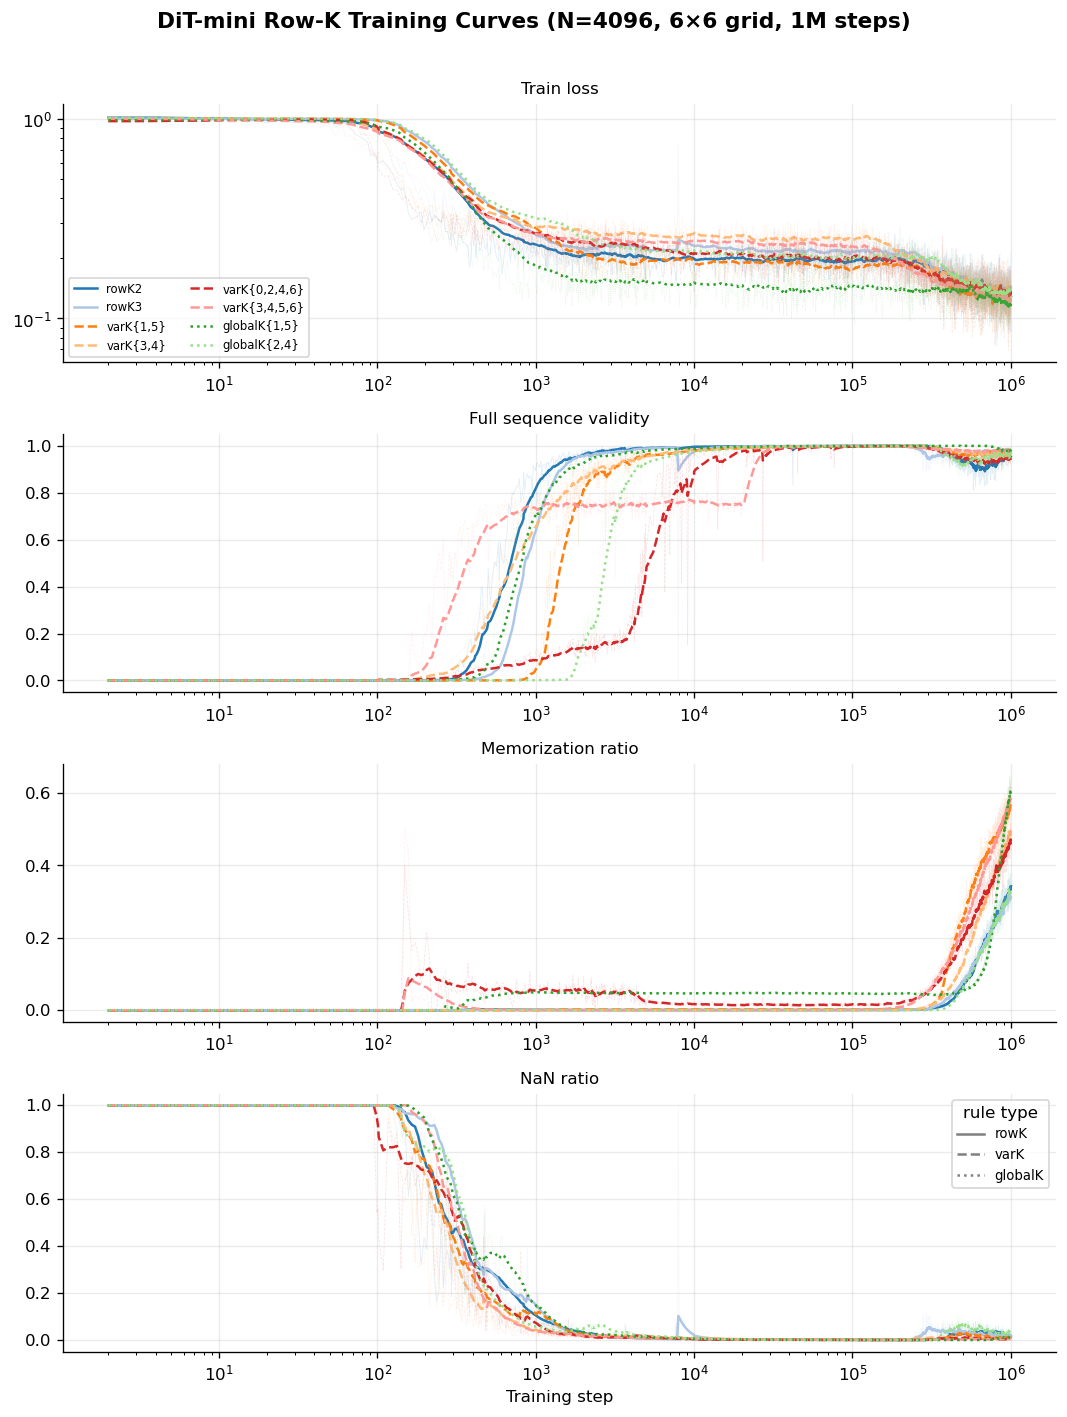

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)
fig.suptitle("DiT-mini Row-K Training Curves (N=4096, 6×6 grid, 1M steps)",
             fontsize=13, fontweight='bold')

panels = [
    ('train/loss',           axes[0], 'Train loss',           True,  0.95),
    ('eval/full_valid_ratio',axes[1], 'Full sequence validity',False, 0.9),
    ('eval/sample_mem_ratio',axes[2], 'Memorization ratio',   False, 0.9),
    ('eval/nan_ratio',       axes[3], 'NaN ratio',            False, 0.9),
]

for tag, ax, title, logy, alpha in panels:
    for lbl in LABELS:
        d = tb_data[lbl].get(tag)
        if d is None: continue
        c  = COLORS[lbl]
        ls = get_ls(lbl)
        ax.plot(d['steps']+1, d['vals'], color=c, lw=0.5, alpha=0.12, ls=ls)
        ax.plot(d['steps']+1, ema_smooth(d['vals'], alpha), color=c, lw=1.5,
                ls=ls, label=lbl)
    ax.set_xscale('log')
    if logy: ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', labelbottom=True)

axes[0].legend(loc='lower left', fontsize=7, ncol=2)
axes[-1].set_xlabel('Training step', fontsize=10)

# Legend: linestyle = rule family
from matplotlib.lines import Line2D
leg_els = [Line2D([0],[0],color='gray',ls=v,lw=1.5,label=k) for k,v in LS.items()]
axes[0].legend(loc='lower left', fontsize=7, ncol=2)
axes[3].legend(handles=leg_els, loc='upper right', fontsize=8, title='rule type')

plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'training_curves')
plt.show()

## 2. Valid / Mem overlay — memorization onset

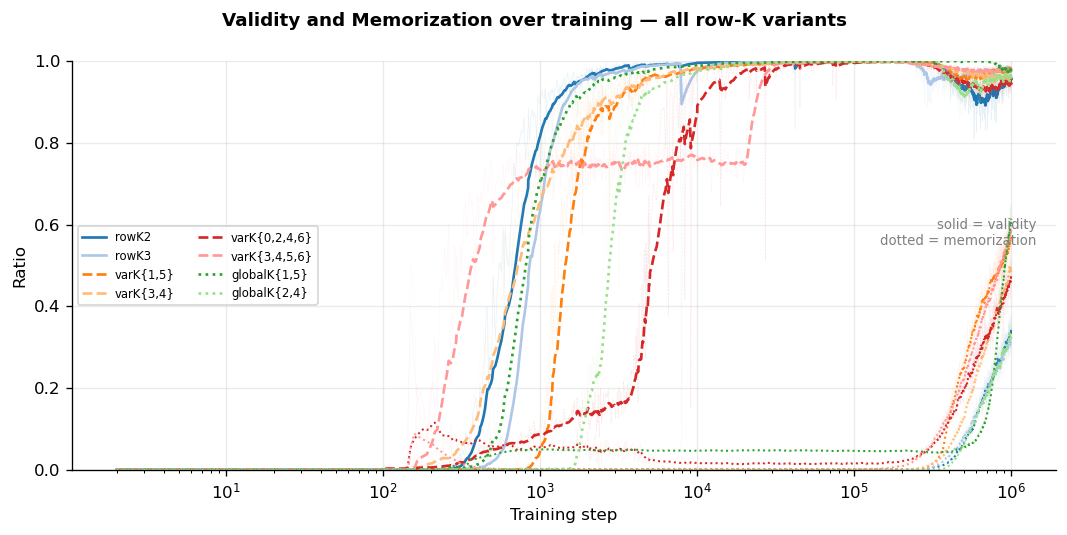

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.suptitle("Validity and Memorization over training — all row-K variants",
             fontsize=11, fontweight='bold')

for lbl in LABELS:
    v = tb_data[lbl].get('eval/full_valid_ratio')
    m = tb_data[lbl].get('eval/sample_mem_ratio')
    c  = COLORS[lbl]
    ls = get_ls(lbl)
    if v is not None:
        ax.plot(v['steps']+1, v['vals'], color=c, lw=0.4, alpha=0.1, ls=ls)
        ax.plot(v['steps']+1, ema_smooth(v['vals'], 0.9), color=c, lw=1.6,
                ls=ls, label=lbl)
    if m is not None:
        ax.plot(m['steps']+1, m['vals'], color=c, lw=0.4, alpha=0.1, ls=':')
        ax.plot(m['steps']+1, ema_smooth(m['vals'], 0.9), color=c, lw=1.2, ls=':')

ax.set_xscale('log')
ax.set_ylim(0, 1)
ax.set_xlabel('Training step', fontsize=10)
ax.set_ylabel('Ratio', fontsize=10)
ax.text(0.98, 0.55, 'solid = validity\ndotted = memorization',
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')
ax.legend(fontsize=7, ncol=2, loc='center left')
ax.grid(alpha=0.25)
plt.tight_layout()
savefig(fig, 'valid_mem_overlay')
plt.show()

## 3. Grad norm evolution

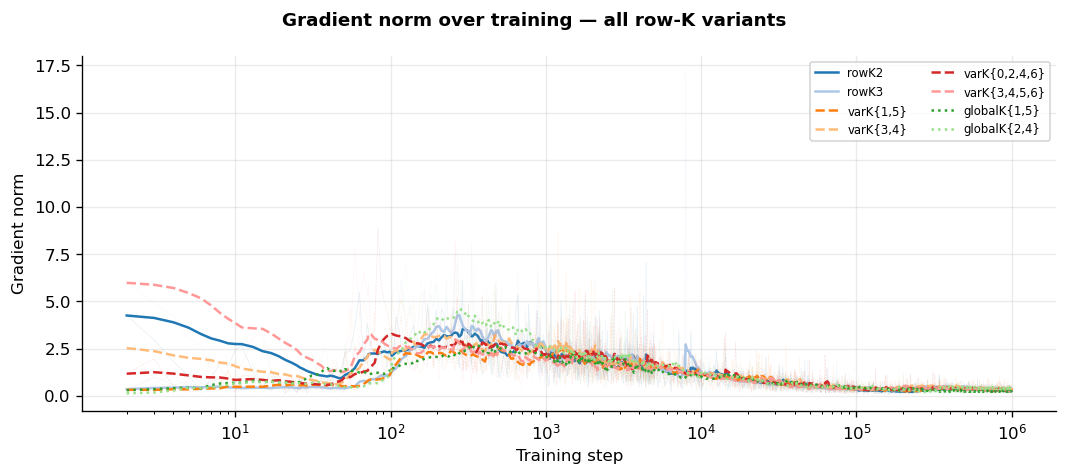

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Gradient norm over training — all row-K variants",
             fontsize=11, fontweight='bold')

for lbl in LABELS:
    d = tb_data[lbl].get('train/grad_norm')
    if d is None: continue
    c  = COLORS[lbl]
    ls = get_ls(lbl)
    ax.plot(d['steps']+1, d['vals'], color=c, lw=0.4, alpha=0.12, ls=ls)
    ax.plot(d['steps']+1, ema_smooth(d['vals'], 0.9), color=c, lw=1.5,
            ls=ls, label=lbl)

ax.set_xscale('log')
ax.set_xlabel('Training step', fontsize=10)
ax.set_ylabel('Gradient norm', fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
savefig(fig, 'grad_norm')
plt.show()

## 4. Crash correlation: late training zoom (EWM α=0.95)

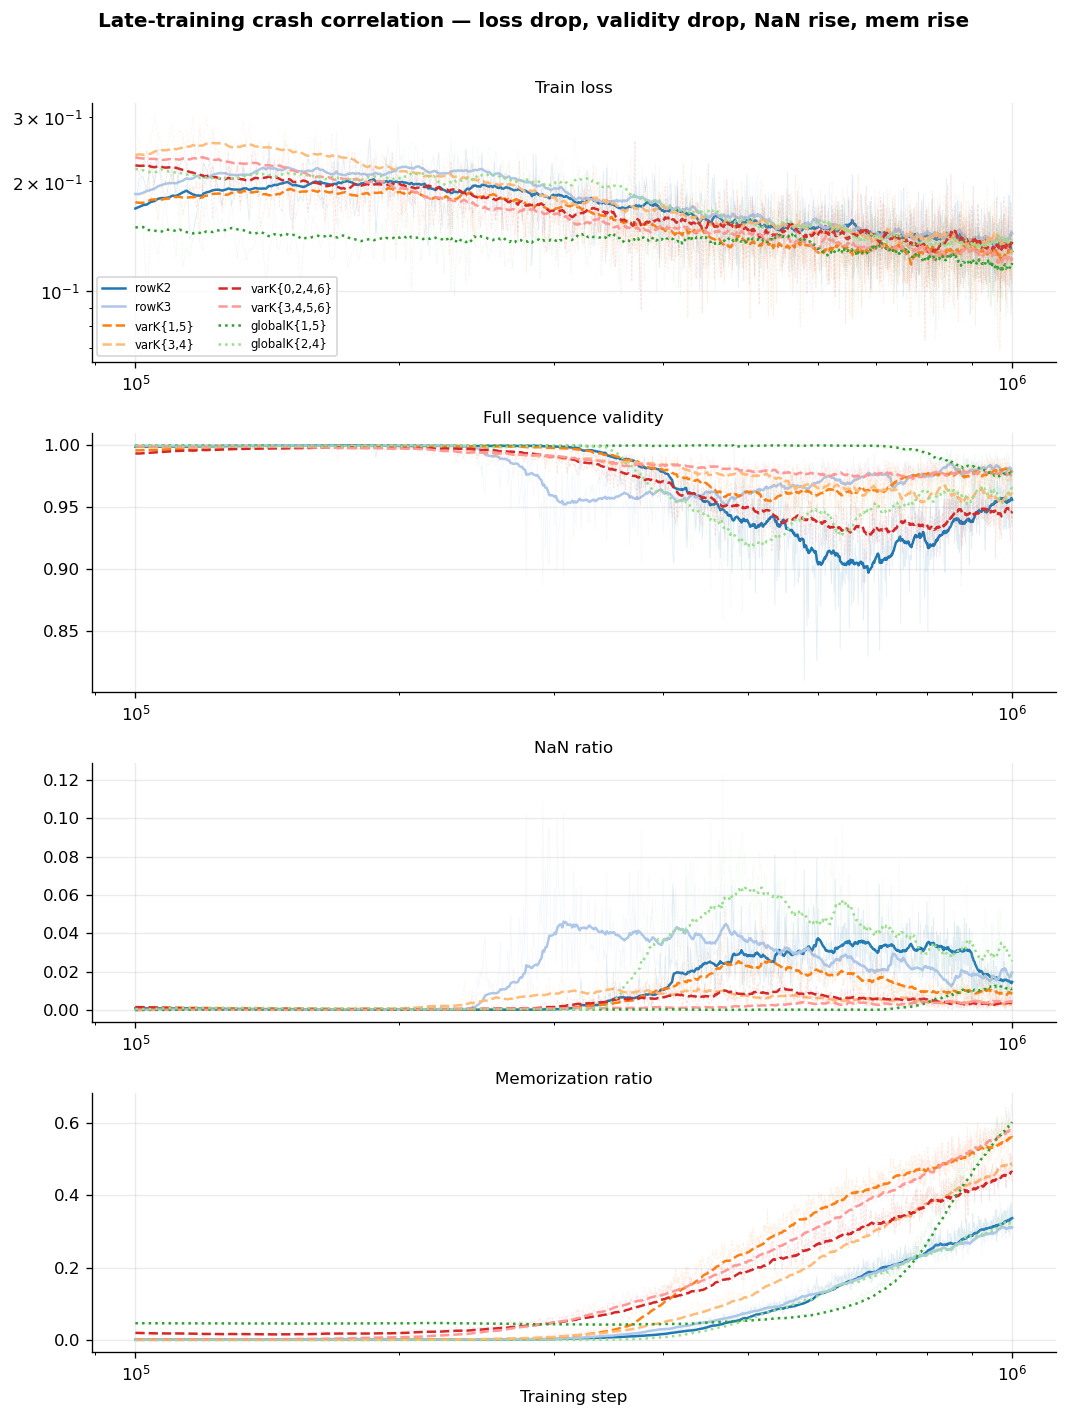

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)
fig.suptitle("Late-training crash correlation — loss drop, validity drop, NaN rise, mem rise",
             fontsize=12, fontweight='bold')

panels = [
    ('train/loss',           axes[0], 'Train loss',           True,  0.95),
    ('eval/full_valid_ratio',axes[1], 'Full sequence validity',False, 0.95),
    ('eval/nan_ratio',       axes[2], 'NaN ratio',            False, 0.95),
    ('eval/sample_mem_ratio',axes[3], 'Memorization ratio',   False, 0.95),
]

STEP_MIN = 1e5   # zoom into steps > 100k

for tag, ax, title, logy, alpha in panels:
    for lbl in LABELS:
        d = tb_data[lbl].get(tag)
        if d is None: continue
        mask = d['steps'] >= STEP_MIN
        if not mask.any(): continue
        steps = d['steps'][mask] + 1
        vals  = d['vals'][mask]
        c  = COLORS[lbl]
        ls = get_ls(lbl)
        ax.plot(steps, vals, color=c, lw=0.5, alpha=0.12, ls=ls)
        ax.plot(steps, ema_smooth(vals, alpha), color=c, lw=1.5, ls=ls, label=lbl)
    ax.set_xscale('log')
    if logy: ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', labelbottom=True)

axes[0].legend(loc='lower left', fontsize=7, ncol=2)
axes[-1].set_xlabel('Training step', fontsize=10)
plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'crash_correlation_zoom')
plt.show()

## 5. σ-loss evolution (DSM loss vs training step, per σ bin)

In [7]:
# Add script dir to path so we can import directly
sys.path.insert(0, '/n/home12/binxuwang/Github/DiffusionAttnConsistency/scripts')
from plot_sigma_loss_evolution import (
    load_sigma_data, bin_mean, SIGMA_BINS, SIGMA_BINS_ZOOM, SPLIT_STYLES
)

# Load sigma loss records for all 8 runs
sigma_records = {}
for lbl, exp, _ in EXPS:
    try:
        sigma_records[lbl] = load_sigma_data(exp)
        print(f"{lbl:20s}: {len(sigma_records[lbl])} checkpoints")
    except Exception as e:
        print(f"{lbl:20s}: ERROR — {e}")
        sigma_records[lbl] = []

rowK2               : 39 checkpoints


rowK3               : 39 checkpoints
varK{1,5}           : 39 checkpoints


varK{3,4}           : 39 checkpoints
varK{0,2,4,6}       : 39 checkpoints


varK{3,4,5,6}       : 39 checkpoints
globalK{1,5}        : 39 checkpoints


globalK{2,4}        : 39 checkpoints


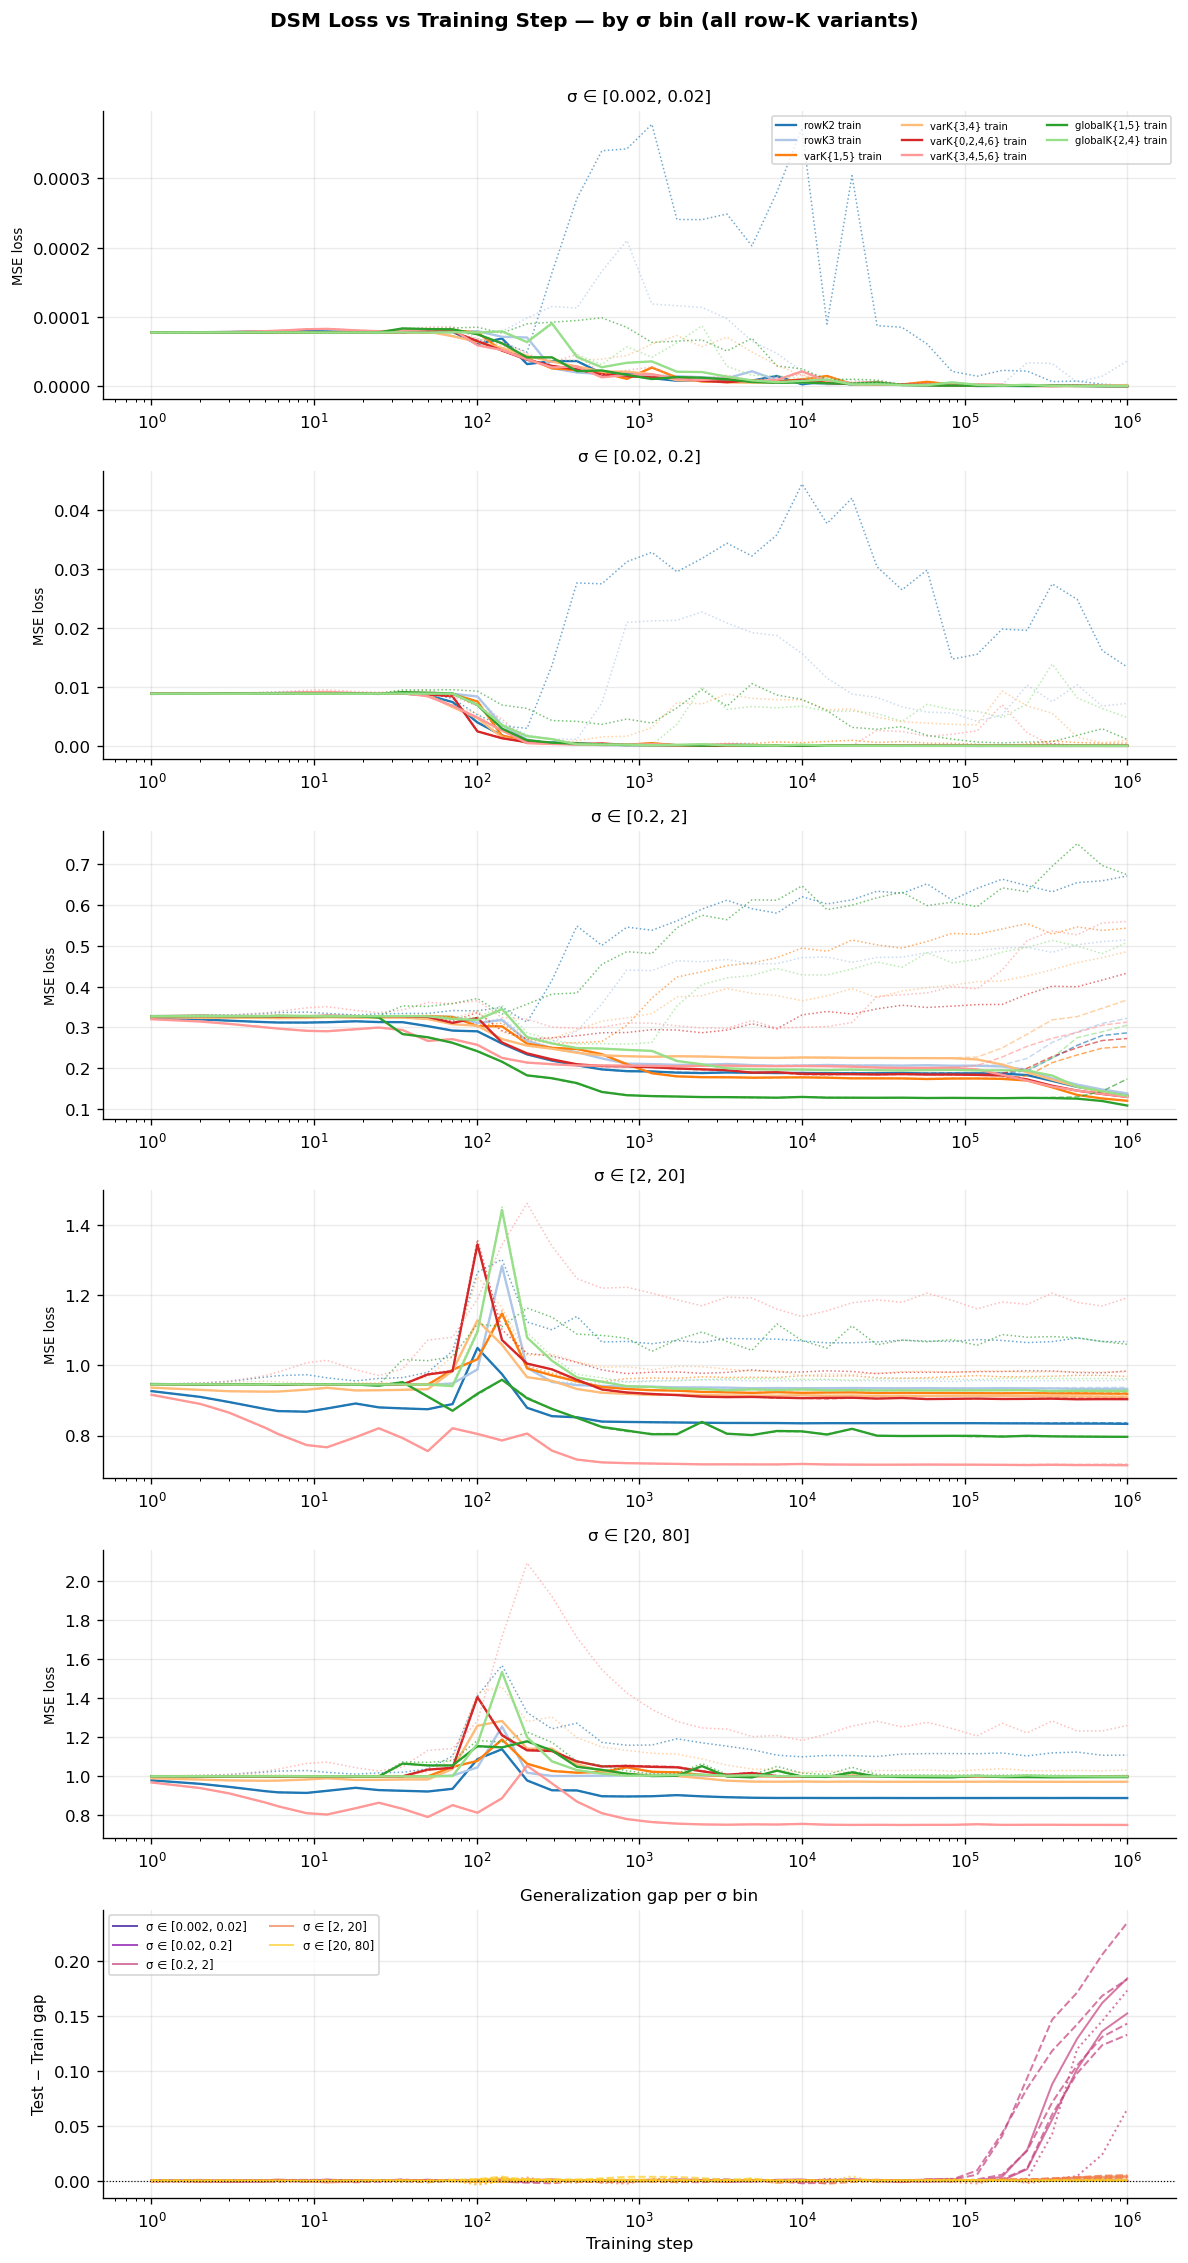

In [8]:
# Plot σ-loss evolution: one panel per σ bin, one line set per run
n_bins = len(SIGMA_BINS)
fig, axes = plt.subplots(n_bins + 1, 1, figsize=(10, 3.2*(n_bins+1)), sharex=True)
fig.suptitle("DSM Loss vs Training Step — by σ bin (all row-K variants)",
             fontsize=12, fontweight='bold')

for b_idx, (bin_label, smin, smax) in enumerate(SIGMA_BINS):
    ax = axes[b_idx]
    for lbl in LABELS:
        recs = sigma_records[lbl]
        if not recs: continue
        steps = np.array([r['epoch'] for r in recs])
        sg    = recs[0]['sigma_grid']
        c = COLORS[lbl]; ls = get_ls(lbl)
        for split, sty in [('train','-'),('test','--'),('random',':')]:
            vals = np.array([bin_mean(r[f'loss_{split}'], sg, smin, smax) for r in recs])
            mask = ~np.isnan(vals)
            lbl_str = f"{lbl} {split}" if (b_idx == 0 and split == 'train') else None
            ax.plot((steps+1)[mask], vals[mask], color=c, lw=1.4 if split=='train' else 0.9,
                    ls=sty, alpha=1.0 if split=='train' else 0.65, label=lbl_str)
    ax.set_xscale('log')
    ax.set_title(bin_label, fontsize=10)
    ax.set_ylabel('MSE loss', fontsize=8)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', which='both', labelbottom=True)

# Gap panel: test-train per bin per run
ax_gap = axes[-1]
bin_cols = plt.cm.plasma(np.linspace(0.05, 0.9, n_bins))
for b_idx, (bin_label, smin, smax) in enumerate(SIGMA_BINS):
    for lbl in LABELS:
        recs = sigma_records[lbl]
        if not recs: continue
        steps = np.array([r['epoch'] for r in recs])
        sg    = recs[0]['sigma_grid']
        tv = np.array([bin_mean(r['loss_train'], sg, smin, smax) for r in recs])
        te = np.array([bin_mean(r['loss_test'],  sg, smin, smax) for r in recs])
        gap  = te - tv
        mask = ~np.isnan(gap)
        ax_gap.plot((steps+1)[mask], gap[mask], color=bin_cols[b_idx],
                    lw=1.2, ls=get_ls(lbl), alpha=0.7,
                    label=bin_label if lbl == LABELS[0] else None)

ax_gap.set_xscale('log')
ax_gap.set_xlabel('Training step', fontsize=10)
ax_gap.set_ylabel('Test − Train gap', fontsize=9)
ax_gap.set_title('Generalization gap per σ bin', fontsize=10)
ax_gap.legend(fontsize=7, ncol=2, loc='upper left')
ax_gap.axhline(0, color='k', lw=0.7, ls=':')
ax_gap.grid(alpha=0.25)

axes[0].legend(fontsize=6, ncol=3, loc='upper right')
plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'sigma_loss_evolution')
plt.show()

## 6. σ-loss curves at pre / during / post divergence checkpoints

In [9]:
# Find divergence epoch per run: first epoch where test-train gap in σ∈[0.2,2] > threshold
THRESH = 0.02
for lbl in LABELS:
    recs = sigma_records[lbl]
    if not recs: continue
    sg = recs[0]['sigma_grid']
    gaps = np.array([
        bin_mean(r['loss_test'], sg, 0.2, 2.0) - bin_mean(r['loss_train'], sg, 0.2, 2.0)
        for r in recs
    ])
    epochs = np.array([r['epoch'] for r in recs])
    div_idx = np.where(gaps > THRESH)[0]
    if len(div_idx):
        print(f"{lbl:20s}: gap first > {THRESH} at idx={div_idx[0]}, ep={epochs[div_idx[0]]:,}  (gap={gaps[div_idx[0]]:.3f})")
    else:
        print(f"{lbl:20s}: gap never > {THRESH} (max={gaps.max():.3f})")

rowK2               : gap first > 0.02 at idx=35, ep=345,511  (gap=0.056)
rowK3               : gap first > 0.02 at idx=34, ep=242,446  (gap=0.028)
varK{1,5}           : gap first > 0.02 at idx=35, ep=345,511  (gap=0.061)
varK{3,4}           : gap first > 0.02 at idx=33, ep=170,125  (gap=0.041)
varK{0,2,4,6}       : gap first > 0.02 at idx=34, ep=242,446  (gap=0.027)
varK{3,4,5,6}       : gap first > 0.02 at idx=33, ep=170,125  (gap=0.044)
globalK{1,5}        : gap first > 0.02 at idx=37, ep=701,704  (gap=0.024)
globalK{2,4}        : gap first > 0.02 at idx=35, ep=345,511  (gap=0.043)


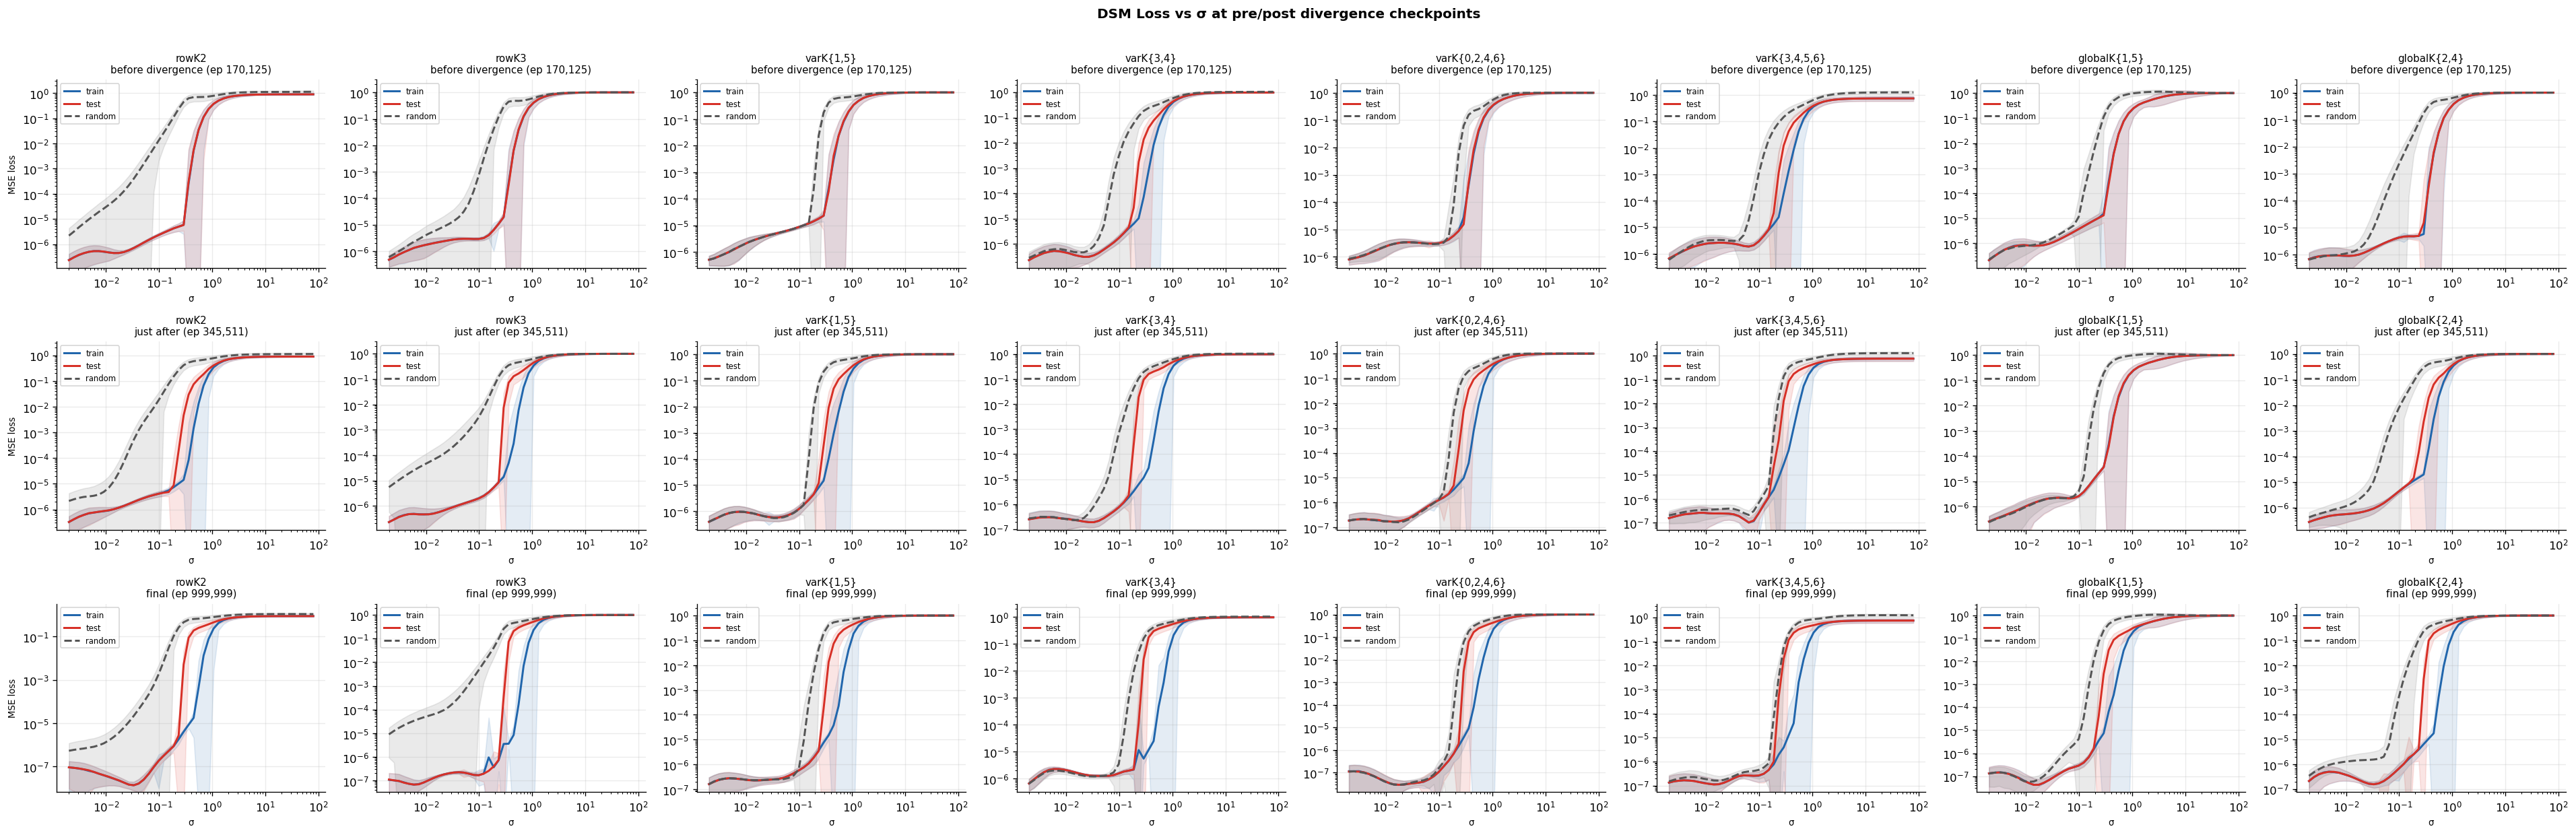

In [10]:
# Show σ-loss curves at 3 time points: before divergence, at divergence, final
# Using rowK2 as the reference run (diverges around ep ~345k, idx 35)

SPLIT_COLORS = {'train': '#2166ac', 'test': '#d73027', 'random': '#555555'}
SPLIT_LS     = {'train': '-',       'test': '-',       'random': '--'}

def draw_sigma_panel(ax, rec, title):
    sigma = rec['sigma_grid']
    all_vals = []
    for split in ['train', 'test', 'random']:
        lv = rec[f'loss_{split}']
        sv = rec[f'std_{split}']
        all_vals.append(lv)
        ax.plot(sigma, lv, color=SPLIT_COLORS[split], lw=1.8,
                ls=SPLIT_LS[split], label=split)
        lo = np.maximum(lv - sv, 1e-9)
        hi = lv + sv
        ax.fill_between(sigma, lo, hi, color=SPLIT_COLORS[split], alpha=0.12)
    ax.set_xscale('log'); ax.set_yscale('log')
    all_concat = np.concatenate(all_vals)
    pos = all_concat[all_concat > 0]
    if len(pos): ax.set_ylim(pos.min()*0.5, pos.max()*3)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('σ', fontsize=8); ax.set_ylabel('MSE loss', fontsize=8)
    ax.legend(fontsize=7, loc='upper left'); ax.grid(alpha=0.25)

time_indices = [33, 35, -1]   # before / just-after / final
time_labels  = ['before divergence', 'just after', 'final']

n_runs = len(LABELS)
n_time = len(time_indices)
fig, axes = plt.subplots(n_time, n_runs, figsize=(4.0*n_runs, 3.5*n_time), squeeze=False)
fig.suptitle("DSM Loss vs σ at pre/post divergence checkpoints",
             fontsize=12, fontweight='bold')

for ti, (widx, tlbl) in enumerate(zip(time_indices, time_labels)):
    for ei, lbl in enumerate(LABELS):
        ax = axes[ti][ei]
        recs = sigma_records[lbl]
        if not recs:
            ax.set_visible(False); continue
        try:
            rec = recs[widx]
        except IndexError:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center')
            continue
        draw_sigma_panel(ax, rec, f"{lbl}\n{tlbl} (ep {rec['epoch']:,})")
        if ei > 0: ax.set_ylabel('')

plt.tight_layout(rect=[0,0,1,0.97])
savefig(fig, 'sigma_curves_checkpoints')
plt.show()

## 7. Final metrics summary

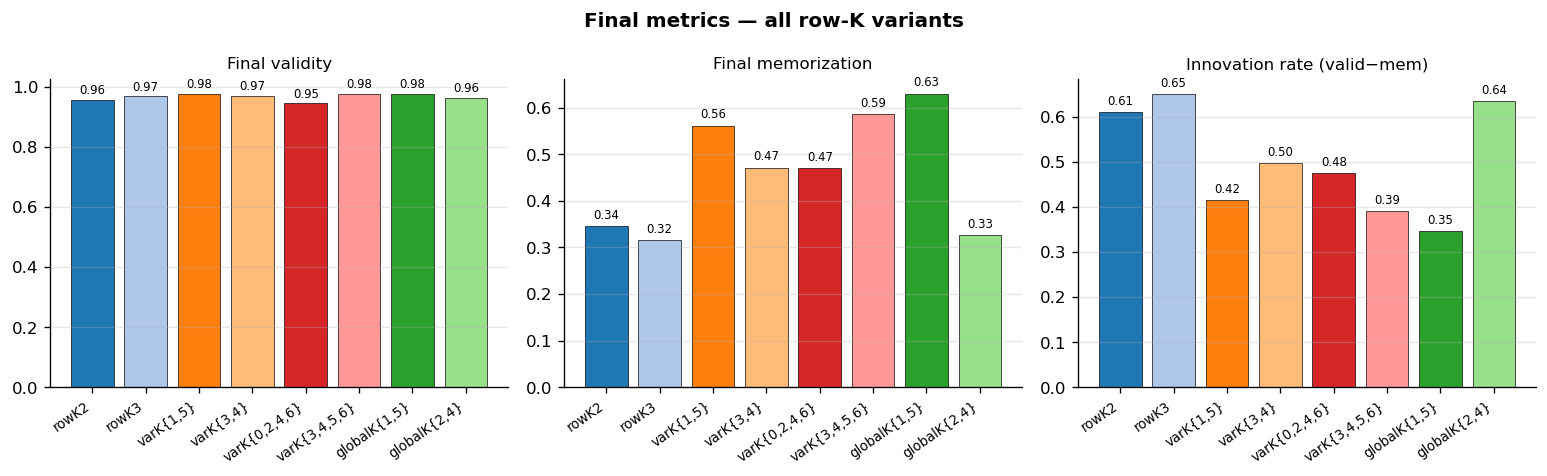

Run                     valid      mem    innov      nan
rowK2                   0.956    0.345    0.611   0.0145
rowK3                   0.967    0.316    0.651   0.0280
varK{1,5}               0.977    0.561    0.416   0.0065
varK{3,4}               0.970    0.471    0.498   0.0015
varK{0,2,4,6}           0.945    0.470    0.476   0.0032
varK{3,4,5,6}           0.977    0.586    0.391   0.0048
globalK{1,5}            0.976    0.630    0.346   0.0109
globalK{2,4}            0.962    0.326    0.636   0.0205


In [11]:
def final_val(lbl, tag, n_avg=5):
    d = tb_data[lbl].get(tag)
    if d is None or len(d['vals']) == 0: return np.nan
    return float(d['vals'][-n_avg:].mean())

valid_f = [final_val(l, 'eval/full_valid_ratio') for l in LABELS]
mem_f   = [final_val(l, 'eval/sample_mem_ratio') for l in LABELS]
innov_f = [v - m for v, m in zip(valid_f, mem_f)]
nan_f   = [final_val(l, 'eval/nan_ratio') for l in LABELS]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Final metrics — all row-K variants", fontsize=12, fontweight='bold')
x = np.arange(len(LABELS))
colors = [COLORS[l] for l in LABELS]

for ax, (ys, title) in zip(axes,
        [(valid_f, 'Final validity'), (mem_f, 'Final memorization'), (innov_f, 'Innovation rate (valid−mem)')]):
    bars = ax.bar(x, ys, color=colors, edgecolor='k', lw=0.4)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, ys):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
savefig(fig, 'final_metrics')
plt.show()

print(f"{'Run':20s}  {'valid':>7}  {'mem':>7}  {'innov':>7}  {'nan':>7}")
for l, v, m, iv, n in zip(LABELS, valid_f, mem_f, innov_f, nan_f):
    print(f"{l:20s}  {v:7.3f}  {m:7.3f}  {iv:7.3f}  {n:7.4f}")

## 8. Coverage vs Memorization — what predicts the final mem ratio?

In [12]:
from math import comb

# ── Valid config counts per rule ─────────────────────────────────────────────
RULE_INFO = {
    'rowK2':         dict(rtype='row_k',     K=2,    Klist=None),
    'rowK3':         dict(rtype='row_k',     K=3,    Klist=None),
    'varK{1,5}':     dict(rtype='row_var_k', K=None, Klist=[1,5]),
    'varK{3,4}':     dict(rtype='row_var_k', K=None, Klist=[3,4]),
    'varK{0,2,4,6}': dict(rtype='row_var_k', K=None, Klist=[0,2,4,6]),
    'varK{3,4,5,6}': dict(rtype='row_var_k', K=None, Klist=[3,4,5,6]),
    'globalK{1,5}':  dict(rtype='global_k',  K=None, Klist=[1,5]),
    'globalK{2,4}':  dict(rtype='global_k',  K=None, Klist=[2,4]),
}
N_TRAIN = 4096
n = 6

def compute_valid_configs(rtype, K=None, Klist=None, n=6):
    if rtype == 'row_k':
        per_row = comb(n, K)
        return per_row, per_row ** n
    elif rtype == 'row_var_k':
        per_row = sum(comb(n, k) for k in Klist)
        return per_row, per_row ** n
    elif rtype == 'global_k':
        per_row = sum(comb(n, k) for k in Klist)
        total   = sum(comb(n, k)**n for k in Klist)  # K drawn once for all rows
        return per_row, total

stats = {}
print(f"{'Rule':20s}  {'per_row_cfgs':>14}  {'total_valid':>16}  {'coverage':>10}")
for lbl in LABELS:
    info = RULE_INFO[lbl]
    per_row, total = compute_valid_configs(**info, n=n)
    cov = N_TRAIN / total
    stats[lbl] = dict(per_row=per_row, total=total, coverage=cov)
    print(f"{lbl:20s}  {per_row:14,}  {total:16,}  {cov:.6f}")

Rule                    per_row_cfgs       total_valid    coverage
rowK2                             15        11,390,625  0.000360
rowK3                             20        64,000,000  0.000064
varK{1,5}                         12         2,985,984  0.001372
varK{3,4}                         35     1,838,265,625  0.000002
varK{0,2,4,6}                     32     1,073,741,824  0.000004
varK{3,4,5,6}                     42     5,489,031,744  0.000001
globalK{1,5}                      12            93,312  0.043896
globalK{2,4}                      30        22,781,250  0.000180


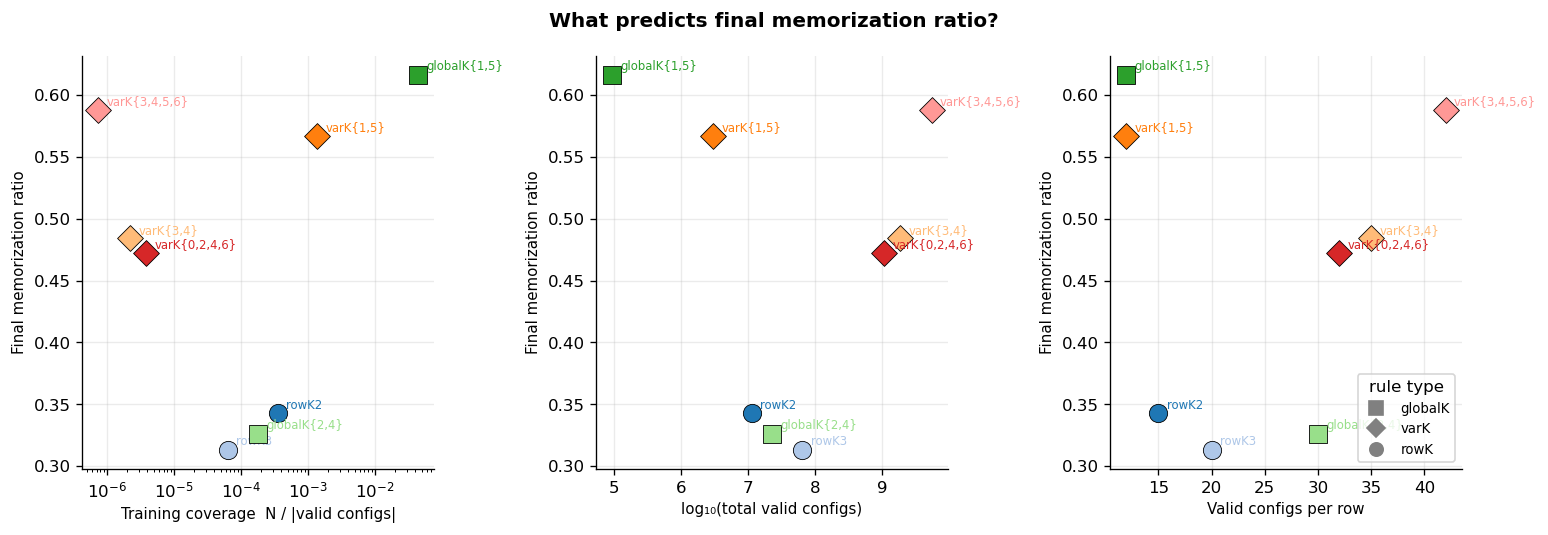

In [13]:
def final_val(lbl, tag, n_avg=10):
    d = tb_data[lbl].get(tag)
    if d is None or len(d['vals']) == 0: return np.nan
    return float(d['vals'][-n_avg:].mean())

mem_f   = {l: final_val(l, 'eval/sample_mem_ratio') for l in LABELS}
valid_f = {l: final_val(l, 'eval/full_valid_ratio')  for l in LABELS}

coverages  = np.array([stats[l]['coverage']  for l in LABELS])
per_rows   = np.array([stats[l]['per_row']   for l in LABELS])
totals     = np.array([stats[l]['total']     for l in LABELS])
mem_vals   = np.array([mem_f[l]   for l in LABELS])
valid_vals = np.array([valid_f[l] for l in LABELS])

# ── Coverage vs final mem ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle("What predicts final memorization ratio?", fontsize=12, fontweight='bold')

rule_types = {'globalK': 's', 'varK': 'D', 'rowK': 'o'}
def get_marker(lbl):
    for k, m in rule_types.items():
        if lbl.startswith(k): return m
    return 'o'

for ax, (xs, xlabel) in zip(axes, [
    (coverages,  'Training coverage  N / |valid configs|'),
    (np.log10(totals),   'log₁₀(total valid configs)'),
    (per_rows,   'Valid configs per row'),
]):
    for lbl in LABELS:
        xi = xs[LABELS.index(lbl)]
        yi = mem_f[lbl]
        ax.scatter(xi, yi, color=COLORS[lbl], s=120, marker=get_marker(lbl),
                   zorder=3, edgecolors='k', lw=0.5)
        ax.annotate(lbl, (xi, yi), textcoords='offset points',
                    xytext=(5, 3), fontsize=7, color=COLORS[lbl])
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Final memorization ratio', fontsize=9)
    ax.grid(alpha=0.25)

axes[0].set_xscale('log')

# Legend for markers
from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker=m, color='gray', ls='none', ms=8, label=k)
       for k, m in rule_types.items()]
axes[2].legend(handles=leg, fontsize=8, title='rule type')

plt.tight_layout()
savefig(fig, 'coverage_vs_memorization')
plt.show()

## 9. GlobalK two-timescale: per-row valid vs full-sequence valid

For `global_k` rules (all rows same K), the model must learn two things:
1. **Per-row constraint**: individual rows should have valid K (K ∈ {1,5} or {2,4})
2. **Global synchronization**: all rows must have the *same* K value

Prediction: per-row valid rises first, full valid rises later once the model synchronizes across rows.
For `row_variable_k` rules each row is independent — no synchronization needed, so per-row ≈ full.

Run                      T50_per_row        T50_full    ratio full/per_row
rowK2                            356             692                  1.94
rowK3                            580             852                  1.47
varK{1,5}                        932           1,444                  1.55
varK{3,4}                        236             708                  3.00
varK{0,2,4,6}                    260           4,996                 19.22
varK{3,4,5,6}                    196             364                  1.86
globalK{1,5}                     444             804                  1.81
globalK{2,4}                   1,844           2,724                  1.48


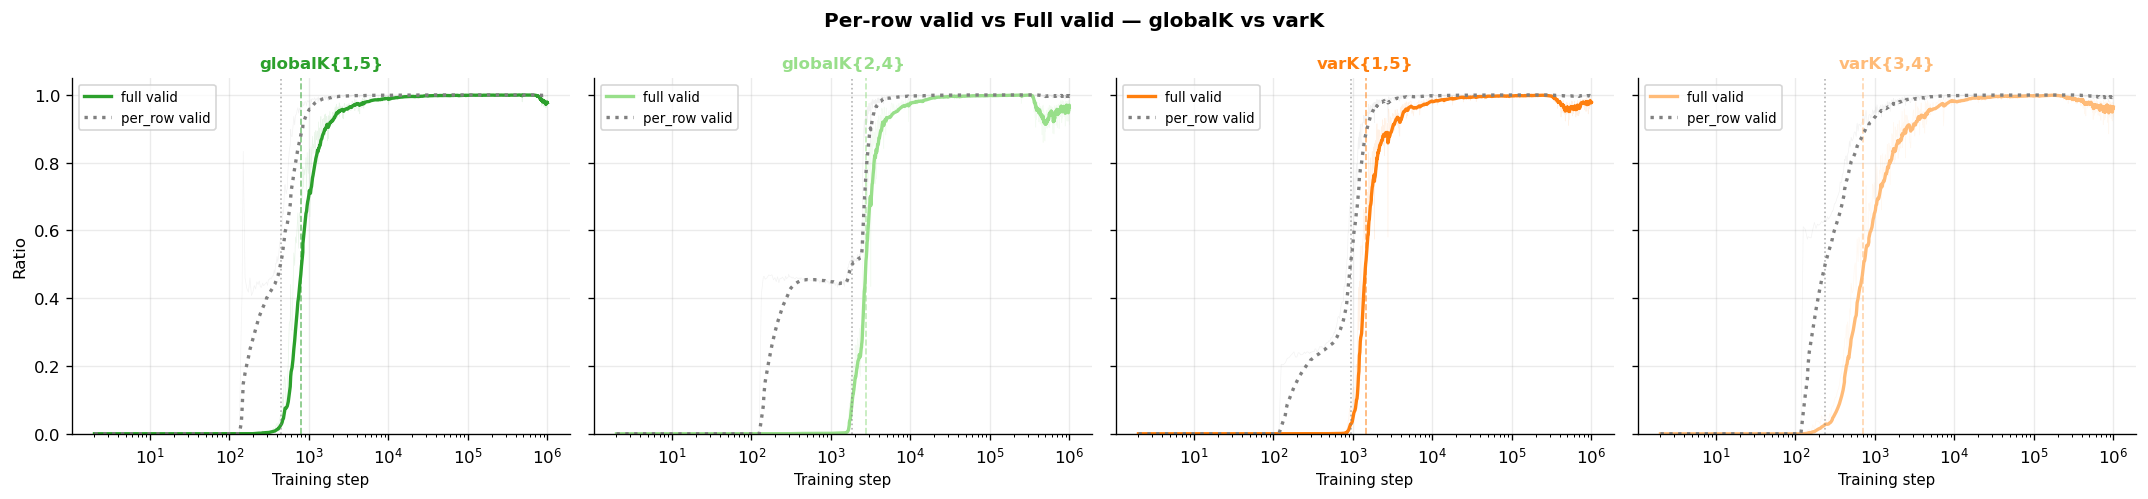

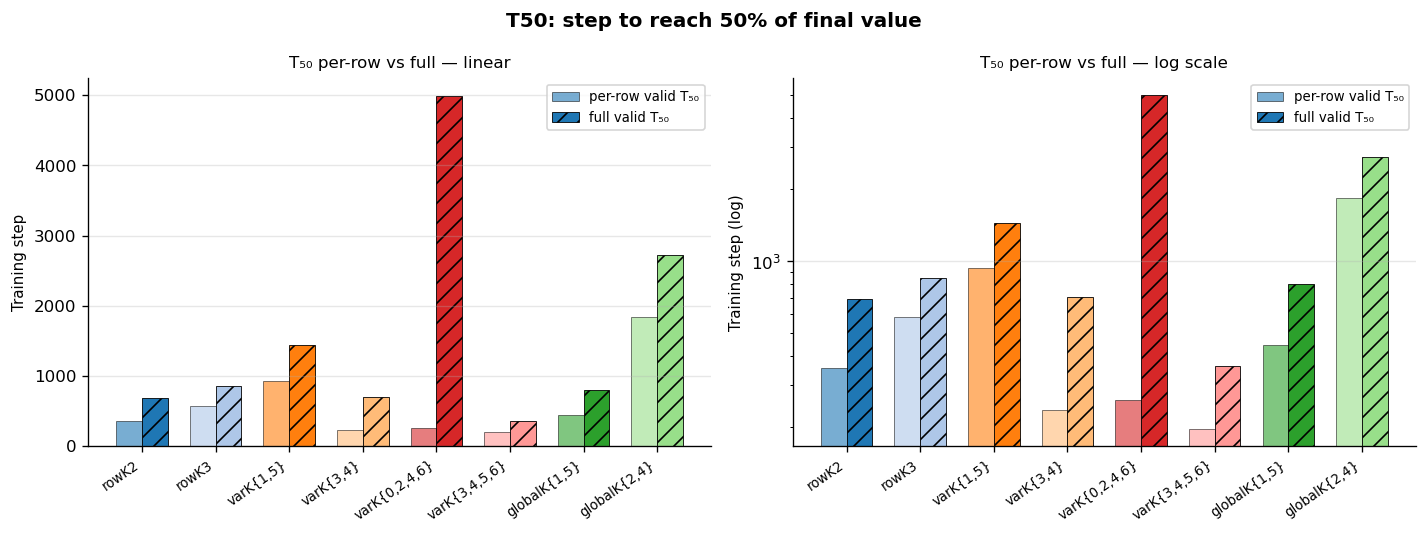

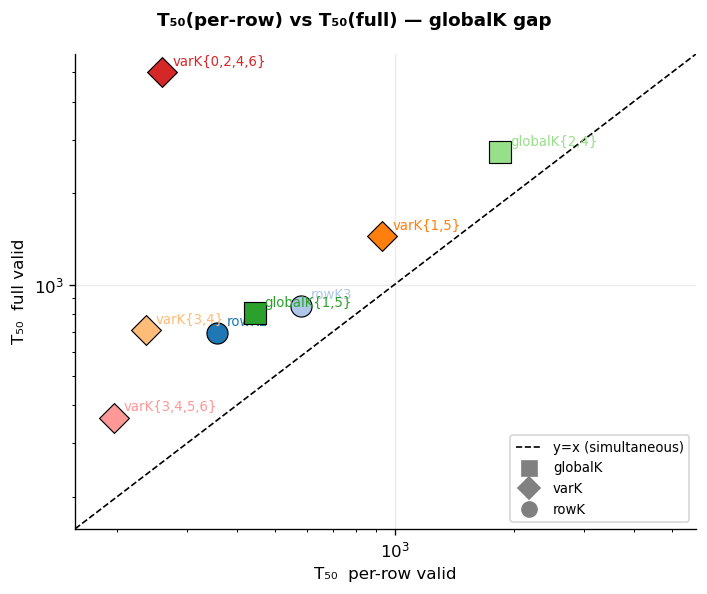

In [14]:
# ── Section 9: GlobalK two-timescale analysis ────────────────────────────────
# Compare timescale of per_row_valid_ratio vs full_valid_ratio
# For globalK rules: expect per_row rises fast, full rises slower (sync needed)
# For varK rules: expect per_row ≈ full (each row independent, no sync needed)

def compute_T50(steps, vals, target_frac=0.5, smooth_alpha=0.9):
    """
    Return the training step where smoothed 'vals' first exceeds
    target_frac * (final smoothed value).
    Returns np.nan if the metric never reaches that level.
    """
    if len(vals) == 0:
        return np.nan
    smoothed = ema_smooth(vals, smooth_alpha)
    final = smoothed[-1]
    threshold = target_frac * final
    idx = np.where(smoothed >= threshold)[0]
    if len(idx) == 0:
        return np.nan
    return float(steps[idx[0]])

# Gather T50 for per_row_valid_ratio and full_valid_ratio
T50_per_row = {}
T50_full    = {}

for lbl in LABELS:
    d_full    = tb_data[lbl].get('eval/full_valid_ratio')
    d_per_row = tb_data[lbl].get('eval/per_row_valid_ratio')

    if d_full is not None:
        T50_full[lbl] = compute_T50(d_full['steps'], d_full['vals'])
    else:
        T50_full[lbl] = np.nan

    if d_per_row is not None:
        T50_per_row[lbl] = compute_T50(d_per_row['steps'], d_per_row['vals'])
    else:
        # fall back: use row_k_valid tag as proxy for per-row validity
        d_rk = tb_data[lbl].get('eval/row_k_valid')
        if d_rk is not None:
            T50_per_row[lbl] = compute_T50(d_rk['steps'], d_rk['vals'])
        else:
            T50_per_row[lbl] = np.nan

print(f"{'Run':20s}  {'T50_per_row':>14}  {'T50_full':>14}  {'ratio full/per_row':>20}")
for lbl in LABELS:
    pr = T50_per_row[lbl]
    fu = T50_full[lbl]
    rat = fu / pr if (not np.isnan(pr) and not np.isnan(fu) and pr > 0) else np.nan
    print(f"{lbl:20s}  {pr:14,.0f}  {fu:14,.0f}  {rat:20.2f}")

# ── Panel 1: raw curves for globalK and varK side-by-side ───────────────────
FOCUS = ['globalK{1,5}', 'globalK{2,4}', 'varK{1,5}', 'varK{3,4}']

fig, axes = plt.subplots(1, len(FOCUS), figsize=(4.5*len(FOCUS), 4.2), sharey=True)
fig.suptitle("Per-row valid vs Full valid — globalK vs varK", fontsize=12, fontweight='bold')

for ax, lbl in zip(axes, FOCUS):
    d_full    = tb_data[lbl].get('eval/full_valid_ratio')
    d_per_row = tb_data[lbl].get('eval/per_row_valid_ratio')
    d_rk      = tb_data[lbl].get('eval/row_k_valid')
    c = COLORS[lbl]

    if d_full is not None:
        ax.plot(d_full['steps']+1, d_full['vals'], color=c, lw=0.4, alpha=0.1)
        sm_full = ema_smooth(d_full['vals'], 0.9)
        ax.plot(d_full['steps']+1, sm_full, color=c, lw=2.0, label='full valid', ls='-')
        t50_f = T50_full[lbl]
        if not np.isnan(t50_f):
            ax.axvline(t50_f, color=c, ls='--', lw=1.0, alpha=0.6)

    per_row_src = d_per_row or d_rk
    per_row_lbl = 'per_row valid' if d_per_row else 'per_row K valid'
    if per_row_src is not None:
        ax.plot(per_row_src['steps']+1, per_row_src['vals'], color='gray', lw=0.4, alpha=0.1)
        sm_pr = ema_smooth(per_row_src['vals'], 0.9)
        ax.plot(per_row_src['steps']+1, sm_pr, color='gray', lw=2.0, label=per_row_lbl, ls=':')
        t50_pr = T50_per_row[lbl]
        if not np.isnan(t50_pr):
            ax.axvline(t50_pr, color='gray', ls=':', lw=1.0, alpha=0.6)

    ax.set_xscale('log')
    ax.set_ylim(0, 1.05)
    ax.set_title(lbl, fontsize=10, color=c, fontweight='bold')
    ax.set_xlabel('Training step', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Ratio', fontsize=10)
plt.tight_layout()
savefig(fig, 'two_timescale_curves')
plt.show()

# ── Panel 2: T50 bar chart comparing per-row vs full for all runs ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("T50: step to reach 50% of final value", fontsize=12, fontweight='bold')

x = np.arange(len(LABELS))
w = 0.35
colors = [COLORS[l] for l in LABELS]
pr_vals = [T50_per_row[l] for l in LABELS]
fu_vals = [T50_full[l]    for l in LABELS]

ax = axes[0]
ax.bar(x - w/2, pr_vals, w, label='per-row valid T₅₀', color=colors,
       alpha=0.6, edgecolor='k', lw=0.5)
ax.bar(x + w/2, fu_vals, w, label='full valid T₅₀', color=colors,
       alpha=1.0, edgecolor='k', lw=0.5, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Training step', fontsize=9)
ax.set_title('T₅₀ per-row vs full — linear', fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.bar(x - w/2, pr_vals, w, color=colors, alpha=0.6, edgecolor='k', lw=0.5,
        label='per-row valid T₅₀')
ax2.bar(x + w/2, fu_vals, w, color=colors, alpha=1.0, edgecolor='k', lw=0.5,
        hatch='//', label='full valid T₅₀')
ax2.set_yscale('log')
ax2.set_xticks(x); ax2.set_xticklabels(LABELS, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Training step (log)', fontsize=9)
ax2.set_title('T₅₀ per-row vs full — log scale', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig(fig, 'two_timescale_T50_bars')
plt.show()

# ── Panel 3: scatter T50_per_row vs T50_full — highlight globalK gap ─────────
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("T₅₀(per-row) vs T₅₀(full) — globalK gap", fontsize=11, fontweight='bold')

for lbl in LABELS:
    pr = T50_per_row[lbl]
    fu = T50_full[lbl]
    ax.scatter(pr, fu, color=COLORS[lbl], s=160, marker=get_marker(lbl),
               zorder=3, edgecolors='k', lw=0.7)
    ax.annotate(lbl, (pr, fu), textcoords='offset points',
                xytext=(6, 4), fontsize=8, color=COLORS[lbl])

lim_max = np.nanmax([*list(T50_per_row.values()), *list(T50_full.values())]) * 1.15
lim_min = np.nanmin([v for v in [*list(T50_per_row.values()), *list(T50_full.values())] if not np.isnan(v)]) * 0.8
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.0)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim_min, lim_max); ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('T₅₀  per-row valid', fontsize=10)
ax.set_ylabel('T₅₀  full valid', fontsize=10)
leg_handles = [
    Line2D([0],[0], color='k', ls='--', lw=1.0, label='y=x (simultaneous)'),
    *[Line2D([0],[0], marker=m, color='gray', ls='none', ms=9, label=k)
      for k, m in rule_types.items()]
]
ax.legend(handles=leg_handles, fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
savefig(fig, 'two_timescale_scatter')
plt.show()


## 10. Sample progression — one figure per experiment, 5 time points

In [15]:
from PIL import Image
import numpy as np

def recolor_montage_border(
    img,
    tile=6,
    grid=8,
    border=1,
    outer=True,
    color=(255, 105, 180),
):
    rgb  = img.convert("RGB")
    arr  = np.array(rgb)
    H, W, _ = arr.shape

    expected_with    = grid * tile + (grid + 1) * border
    expected_without = grid * tile + (grid - 1) * border
    if (H, W) == (expected_with, expected_with):
        outer = True
    elif (H, W) == (expected_without, expected_without):
        outer = False
    else:
        print(f"[warn] image is {H}x{W}; expected {expected_with} (outer) or "
              f"{expected_without} (no outer). Using outer={outer}.")

    mask = np.zeros((H, W), dtype=bool)
    if outer:
        x = 0
        for i in range(grid + 1):
            mask[:, x:x + border] = True
            x += border
            if i < grid: x += tile
        y = 0
        for i in range(grid + 1):
            mask[y:y + border, :] = True
            y += border
            if i < grid: y += tile
    else:
        x = tile
        for i in range(grid - 1):
            mask[:, x:x + border] = True
            x += border + tile
        y = tile
        for i in range(grid - 1):
            mask[y:y + border, :] = True
            y += border + tile

    arr[mask] = color
    return Image.fromarray(arr)


def detect_layout(img, candidate_grids=(8, 10, 12, 16), candidate_tiles=(4, 6, 8, 10, 14, 16, 28)):
    W, H = img.size
    if W != H:
        print(f"[warn] non-square image {W}x{H}; layout detection may be off")
    side = W
    for g in candidate_grids:
        for t in candidate_tiles:
            for b in (1, 2):
                if side == g * t + (g + 1) * b:
                    return dict(grid=g, tile=t, border=b, outer=True)
                if side == g * t + (g - 1) * b:
                    return dict(grid=g, tile=t, border=b, outer=False)
    return None


def get_sample_pngs(exp_name):
    samples_dir = os.path.join(SAVEROOT, exp_name, 'samples')
    return sorted(f for f in os.listdir(samples_dir) if f.endswith('.png'))


EPOCH_LABELS = ['initial', 'early', 'mid', 'late', 'final']
BORDER_COLOR = (255, 170, 170)   # light pink

print("Helper functions defined.")

Helper functions defined.


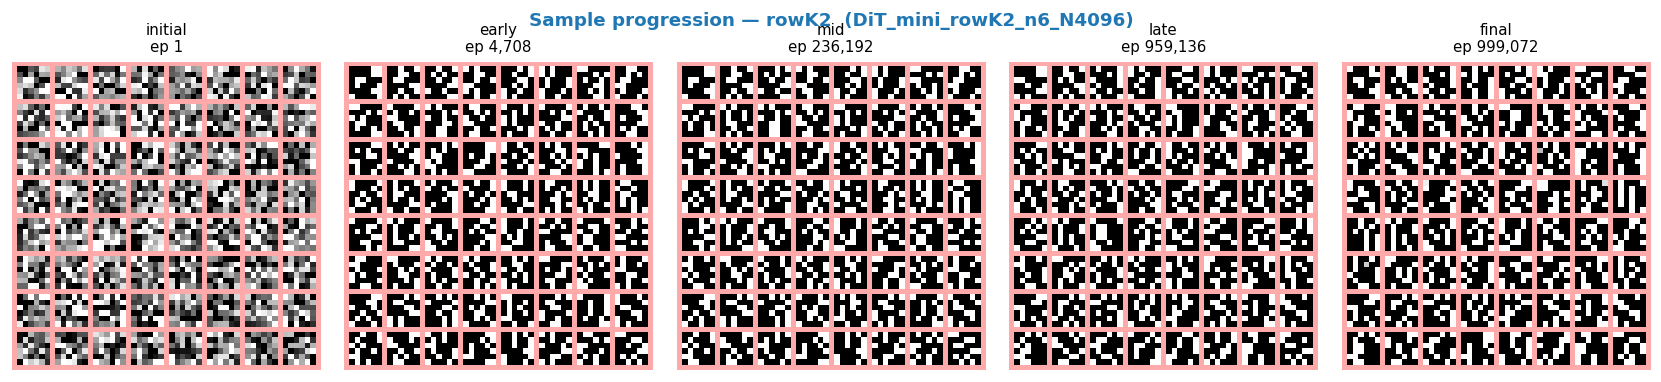

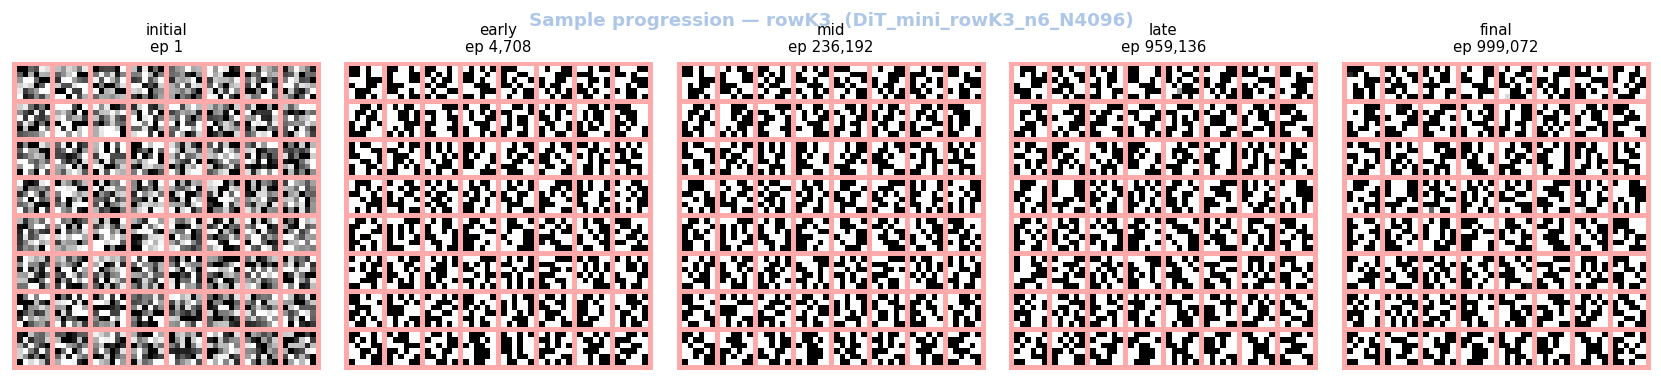

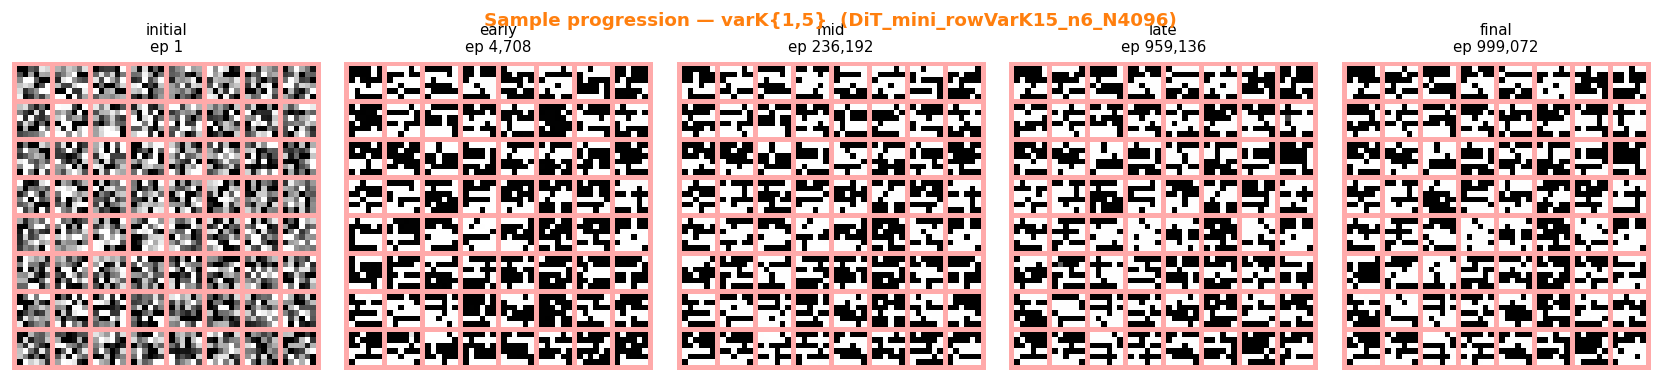

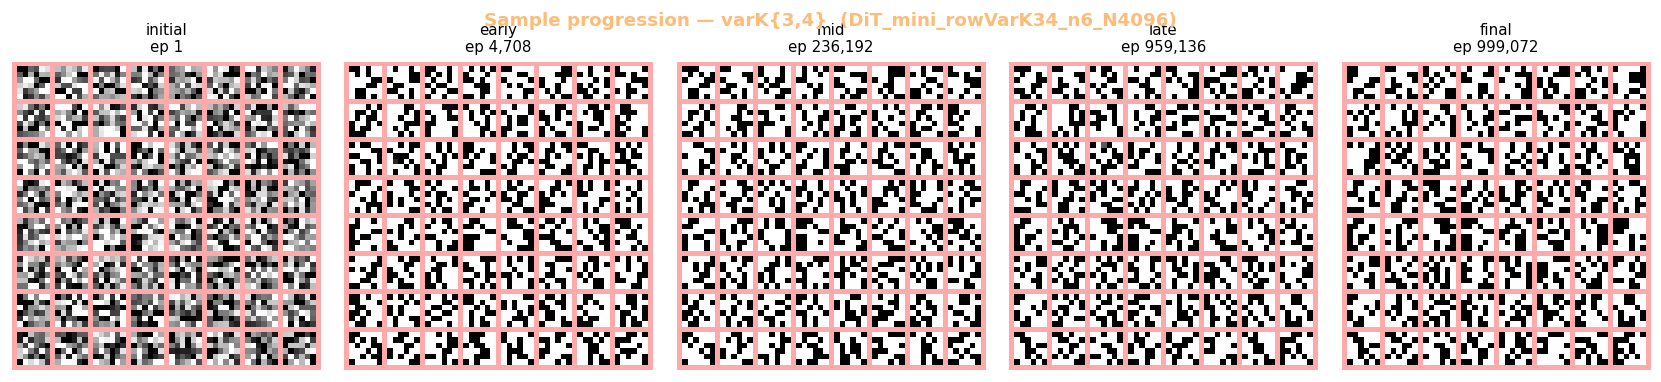

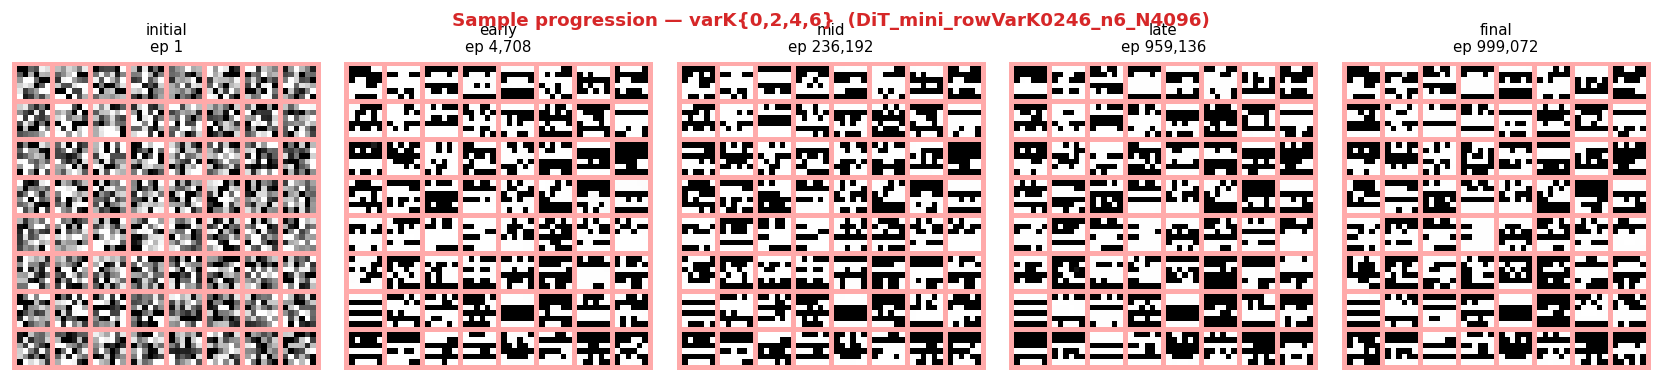

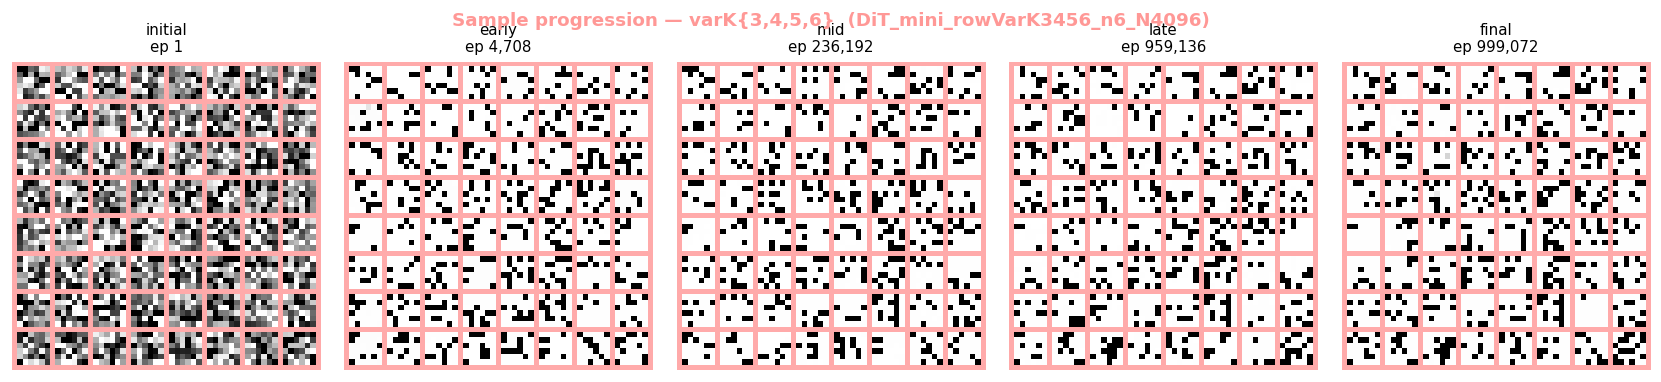

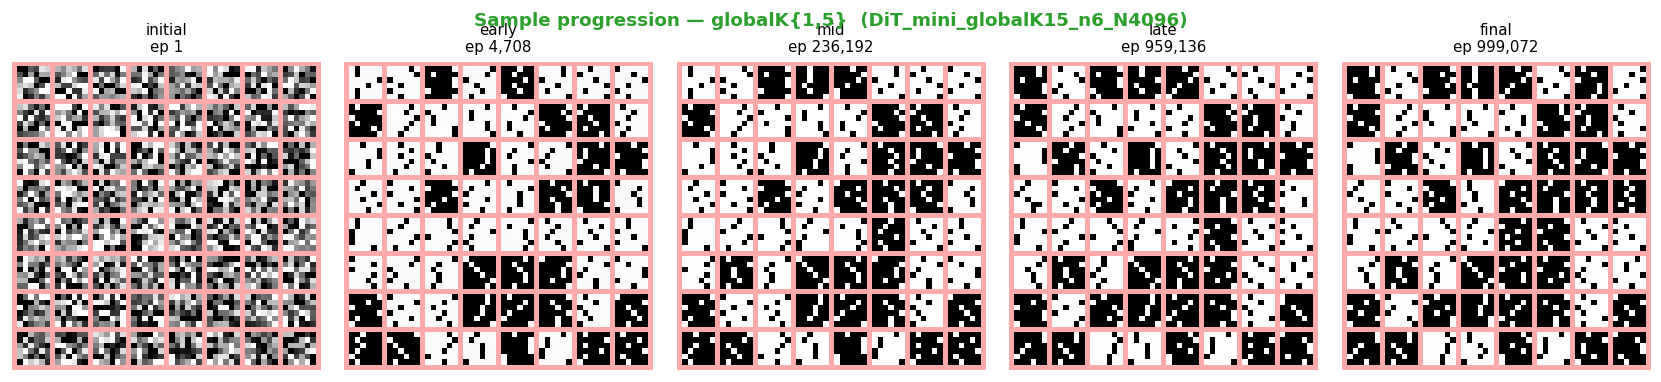

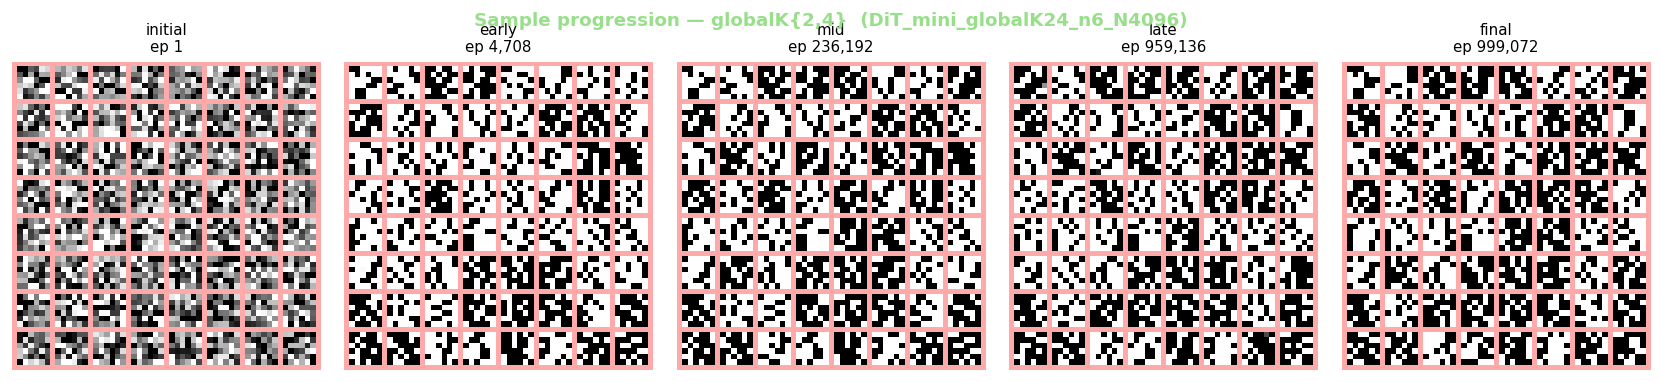

In [16]:
# One figure per experiment — 5 time points across training
for lbl, exp_name, color in EXPS:
    pngs = get_sample_pngs(exp_name)
    n = len(pngs)
    indices = [0, n // 5, n // 2, max(0, n - 40), n - 1]

    fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
    fig.suptitle(f"Sample progression — {lbl}  ({exp_name})",
                 fontsize=11, fontweight='bold', color=color)

    for ci, (idx, stage) in enumerate(zip(indices, EPOCH_LABELS)):
        ax = axes[ci]
        img_path = os.path.join(SAVEROOT, exp_name, 'samples', pngs[idx])
        img = Image.open(img_path)
        layout = detect_layout(img)
        if layout is None:
            ax.text(0.5, 0.5, 'layout?', ha='center', va='center', transform=ax.transAxes)
        else:
            out = recolor_montage_border(img, **layout, color=BORDER_COLOR)
            ax.imshow(out, interpolation='nearest')
        ax.axis('off')
        ep_str = pngs[idx].replace('samples_epoch_', '').replace('.png', '')
        ep = int(ep_str)
        ax.set_title(f"{stage}\nep {ep:,}", fontsize=9)

    plt.tight_layout()
    savefig(fig, f'samples_progression_{lbl.replace("{","").replace("}","").replace(",","")}')
    plt.show()
